# Model Evaluation and What-if Business Insights

## Business Goal

This notebook evaluates the final machine learning model and extends it into a business decision-support system.

Instead of only checking accuracy, this notebook answers:

- How reliable is the model?
- What profit can be expected under different business scenarios?
- Which business decisions improve predicted profit?
- How can managers use the model for factory optimization?

In [30]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [31]:
data_path = Path("../data/processed")
model_path = Path("../models")

df = pd.read_csv(data_path / "factory_sales_feature_engineered.csv")
model = joblib.load(model_path / "gradient_boosting_model.pkl")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)
print("Model loaded successfully")

Dataset loaded successfully
Dataset shape: (10194, 30)
Model loaded successfully


# Preparing Data for Evaluation

The model requires the same features used during training.

This section prepares the dataset by:

- Selecting model features
- Encoding categorical variables
- Matching the feature order used during training

In [32]:
# Features used during training

features = [
    "Sales",
    "Cost",
    "Units",
    "High Value Order",
    "Order Year",
    "Order Month",
    "Order Quarter",
    "Is Weekend",
    "Ship Mode",
    "Region",
    "Sales Category"
]

X = df[features]
y = df["Gross Profit"]

X_encoded = pd.get_dummies(
    X,
    columns=[
        "Ship Mode",
        "Region",
        "Sales Category"
    ],
    drop_first=True
)

X_encoded = X_encoded.reindex(
    columns=model.feature_names_in_,
    fill_value=0
)

print("Feature matrix shape:", X_encoded.shape)

Feature matrix shape: (10194, 15)


# Model Predictions

The trained Gradient Boosting model predicts the expected profit for every order.

The predictions are compared with the actual profit values to evaluate performance.

In [33]:
predictions = model.predict(X_encoded)

comparison = pd.DataFrame({
    "Actual Profit": y,
    "Predicted Profit": predictions
})

comparison["Prediction Error"] = (
    comparison["Predicted Profit"]
    - comparison["Actual Profit"]
)

comparison.head()

,Actual Profit,Predicted Profit,Prediction Error
0,4.22,4.076631,-0.143369
1,4.90,4.922863,0.022863
2,7.47,7.376464,-0.093536
3,7.50,7.376464,-0.123536
4,7.35,7.360165,0.010165


# What-If Business Simulator

Rather than only evaluating historical orders, managers often need to estimate the profit of future scenarios.

This simulator allows different business conditions to be entered and predicts the expected profit using the trained Gradient Boosting model.

In [34]:
def predict_profit(
    sales,
    cost,
    units,
    region,
    ship_mode,
    sales_category,
    high_value_order=0,
    order_year=2024,
    order_month=6,
    order_quarter=2,
    is_weekend=0
):
    
    sample = pd.DataFrame([{
        "Sales": sales,
        "Cost": cost,
        "Units": units,
        "High Value Order": high_value_order,
        "Order Year": order_year,
        "Order Month": order_month,
        "Order Quarter": order_quarter,
        "Is Weekend": is_weekend,
        "Ship Mode": ship_mode,
        "Region": region,
        "Sales Category": sales_category
    }])

    sample = pd.get_dummies(
        sample,
        columns=[
            "Ship Mode",
            "Region",
            "Sales Category"
        ],
        drop_first=True
    )

    sample = sample.reindex(
        columns=model.feature_names_in_,
        fill_value=0
    )

    prediction = model.predict(sample)[0]

    return prediction

# Scenario 1 — Recommended Business Strategy

In [35]:
regions = [
    "Atlantic",
    "Gulf",
    "Interior",
    "Pacific"
]

results = []

for region in regions:

    profit = predict_profit(
        sales=250,
        cost=110,
        units=15,
        region=region,
        ship_mode="Second Class",
        sales_category="High",
        high_value_order=1
    )

    results.append([region, profit])

region_df = pd.DataFrame(
    results,
    columns=[
        "Region",
        "Predicted Profit"
    ]
)

region_df.sort_values(
    by="Predicted Profit",
    ascending=False
)

,Region,Predicted Profit
0,Atlantic,129.167854
1,Gulf,129.167854
2,Interior,129.167854
3,Pacific,129.167854


# Sales Growth Simulation

This experiment estimates how predicted profit changes as sales increase while all other business conditions remain constant.

It helps managers understand the financial impact of increasing revenue.

In [36]:
sales_values = [100, 150, 200, 250, 300, 350, 400]

profits = []

for sale in sales_values:

    predicted = predict_profit(
        sales=sale,
        cost=110,
        units=15,
        region="Pacific",
        ship_mode="Second Class",
        sales_category="High",
        high_value_order=1
    )

    profits.append(predicted)

sales_df = pd.DataFrame({
    "Sales": sales_values,
    "Predicted Profit": profits
})

sales_df

,Sales,Predicted Profit
0,100,64.558339
1,150,95.703537
2,200,119.364483
3,250,129.167854
4,300,129.167854
5,350,129.167854
6,400,129.167854


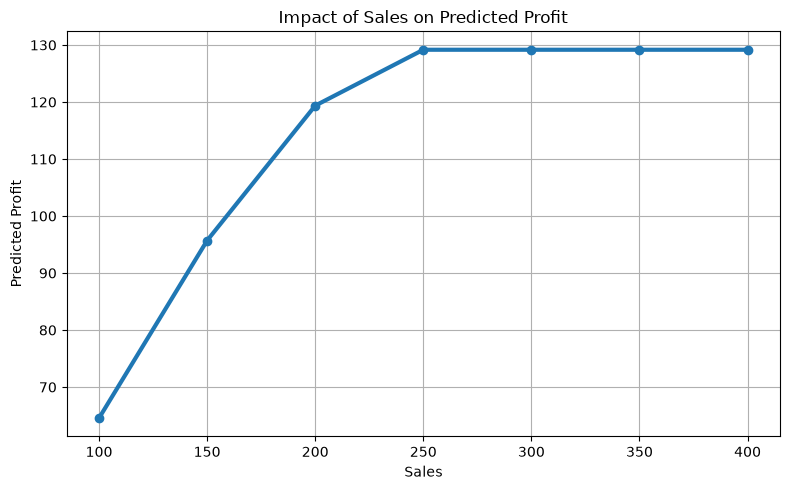

In [40]:
plt.figure(figsize=(8,5))

plt.plot(
    sales_df["Sales"],
    sales_df["Predicted Profit"],
    marker="o",
    linewidth=3
)

plt.title("Impact of Sales on Predicted Profit")
plt.xlabel("Sales")
plt.ylabel("Predicted Profit")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../reports/figures/sales_growth_simulation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
cost_values = [80, 100, 120, 140, 160]

profits = []

for cost in cost_values:

    predicted = predict_profit(
        sales=250,
        cost=cost,
        units=15,
        region="Pacific",
        ship_mode="Second Class",
        sales_category="High",
        high_value_order=1
    )

    profits.append(predicted)

cost_df = pd.DataFrame({
    "Cost": cost_values,
    "Predicted Profit": profits
})

cost_df

,Cost,Predicted Profit
0,80,129.167854
1,100,129.167854
2,120,129.167854
3,140,129.167854
4,160,129.167854


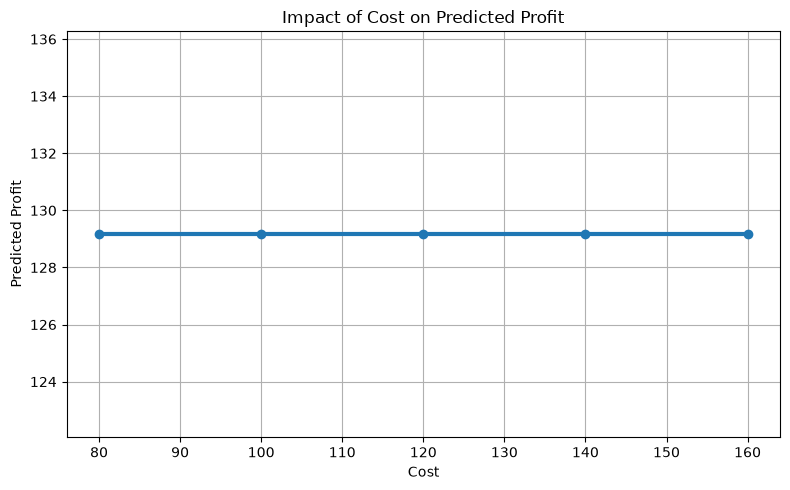

In [41]:
plt.figure(figsize=(8,5))

plt.plot(
    cost_df["Cost"],
    cost_df["Predicted Profit"],
    marker="o",
    linewidth=3
)

plt.title("Impact of Cost on Predicted Profit")
plt.xlabel("Cost")
plt.ylabel("Predicted Profit")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../reports/figures/cost_sensitivity_simulation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

In [43]:
# Shipping mode simulation

ship_modes = ["Standard Class", "Second Class", "First Class", "Same Day"]

profits = []

for mode in ship_modes:
    predicted = predict_profit(
        sales=250,
        cost=110,
        units=15,
        region="Pacific",
        ship_mode=mode,
        sales_category="High",
        high_value_order=1
    )
    profits.append(predicted)

shipping_df = pd.DataFrame({
    "Ship Mode": ship_modes,
    "Predicted Profit": profits
})

shipping_df

,Ship Mode,Predicted Profit
0,Standard Class,129.167854
1,Second Class,129.167854
2,First Class,129.167854
3,Same Day,129.167854


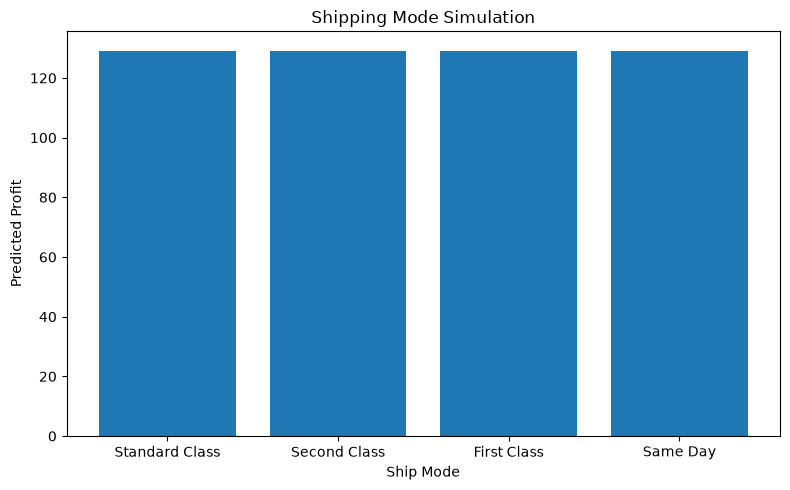

In [44]:
plt.figure(figsize=(8,5))

plt.bar(
    shipping_df["Ship Mode"],
    shipping_df["Predicted Profit"]
)

plt.title("Shipping Mode Simulation")
plt.xlabel("Ship Mode")
plt.ylabel("Predicted Profit")

plt.tight_layout()
plt.savefig(FIGURES / "shipping_mode_simulation.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
# High value order simulation

order_types = ["Normal Order", "High Value Order"]
high_value_flags = [0, 1]

profits = []

for flag in high_value_flags:
    predicted = predict_profit(
        sales=250,
        cost=110,
        units=15,
        region="Pacific",
        ship_mode="Second Class",
        sales_category="High",
        high_value_order=flag
    )
    profits.append(predicted)

high_value_df = pd.DataFrame({
    "Order Type": order_types,
    "Predicted Profit": profits
})

high_value_df

,Order Type,Predicted Profit
0,Normal Order,129.167854
1,High Value Order,129.167854


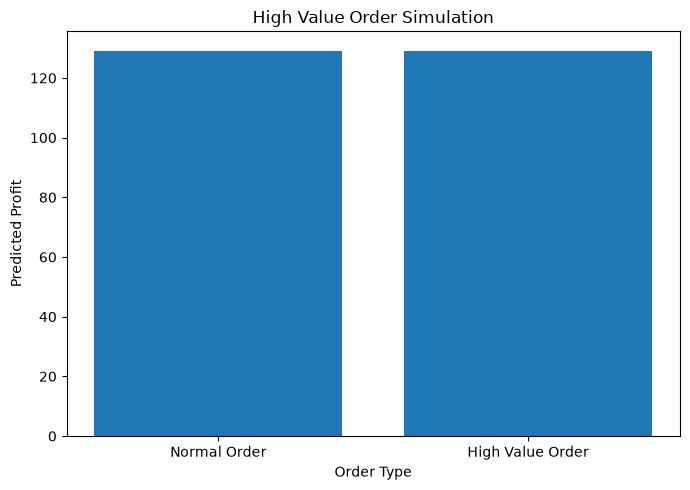

In [46]:
plt.figure(figsize=(7,5))

plt.bar(
    high_value_df["Order Type"],
    high_value_df["Predicted Profit"]
)

plt.title("High Value Order Simulation")
plt.xlabel("Order Type")
plt.ylabel("Predicted Profit")

plt.tight_layout()
plt.savefig(FIGURES / "high_value_order_simulation.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
# Profit sensitivity analysis

baseline_profit = predict_profit(
    sales=250,
    cost=110,
    units=15,
    region="Pacific",
    ship_mode="Second Class",
    sales_category="High",
    high_value_order=1
)

sensitivity_results = {
    "Baseline": baseline_profit,
    "Sales +20%": predict_profit(300, 110, 15, "Pacific", "Second Class", "High", 1),
    "Sales -20%": predict_profit(200, 110, 15, "Pacific", "Second Class", "High", 1),
    "Cost +20%": predict_profit(250, 132, 15, "Pacific", "Second Class", "High", 1),
    "Cost -20%": predict_profit(250, 88, 15, "Pacific", "Second Class", "High", 1),
    "Units +20%": predict_profit(250, 110, 18, "Pacific", "Second Class", "High", 1),
    "Units -20%": predict_profit(250, 110, 12, "Pacific", "Second Class", "High", 1)
}

sensitivity_df = pd.DataFrame({
    "Scenario": list(sensitivity_results.keys()),
    "Predicted Profit": list(sensitivity_results.values())
})

sensitivity_df

,Scenario,Predicted Profit
0,Baseline,129.167854
1,Sales +20%,129.167854
2,Sales -20%,119.364483
3,Cost +20%,129.167854
4,Cost -20%,129.167854
5,Units +20%,129.167854
6,Units -20%,115.673161


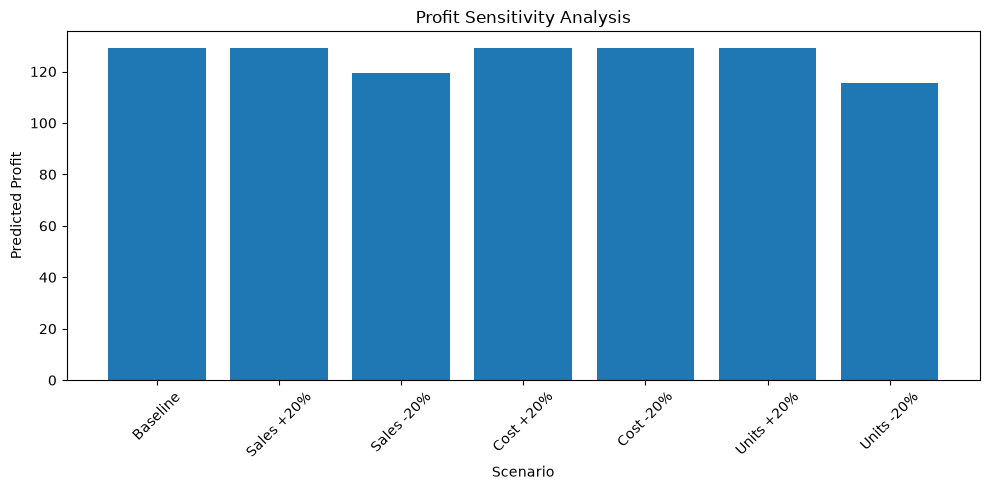

In [48]:
plt.figure(figsize=(10,5))

plt.bar(
    sensitivity_df["Scenario"],
    sensitivity_df["Predicted Profit"]
)

plt.title("Profit Sensitivity Analysis")
plt.xlabel("Scenario")
plt.ylabel("Predicted Profit")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(FIGURES / "profit_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

In [49]:
# Best strategy heatmap

regions = ["Atlantic", "Gulf", "Interior", "Pacific"]
ship_modes = ["Standard Class", "Second Class", "First Class", "Same Day"]

heatmap_data = []

for region in regions:
    row = []
    for mode in ship_modes:
        predicted = predict_profit(
            sales=250,
            cost=110,
            units=15,
            region=region,
            ship_mode=mode,
            sales_category="High",
            high_value_order=1
        )
        row.append(predicted)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(
    heatmap_data,
    index=regions,
    columns=ship_modes
)

heatmap_df

,Standard Class,Second Class,First Class,Same Day
Atlantic,129.167854,129.167854,129.167854,129.167854
Gulf,129.167854,129.167854,129.167854,129.167854
Interior,129.167854,129.167854,129.167854,129.167854
Pacific,129.167854,129.167854,129.167854,129.167854


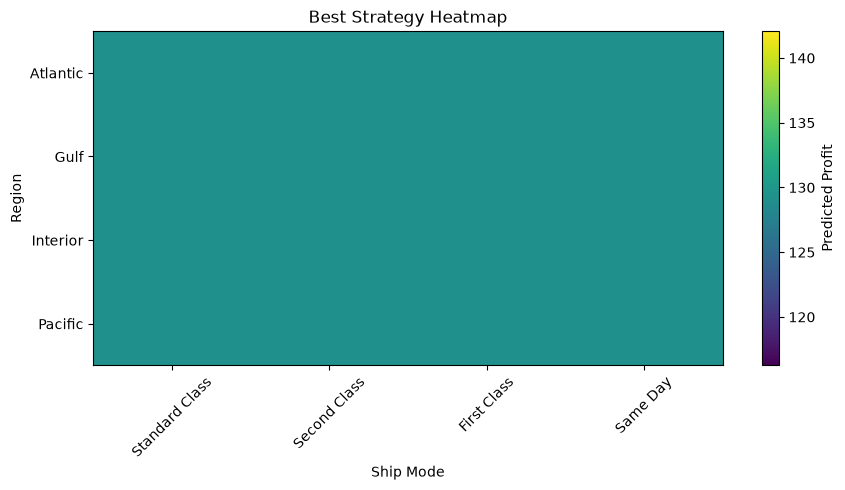

In [50]:
plt.figure(figsize=(9,5))

plt.imshow(heatmap_df, aspect="auto")
plt.colorbar(label="Predicted Profit")

plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=45)
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)

plt.title("Best Strategy Heatmap")
plt.xlabel("Ship Mode")
plt.ylabel("Region")

plt.tight_layout()
plt.savefig(FIGURES / "best_strategy_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Automatic Business Recommendations

This section converts simulation results into clear business recommendations for management.

In [51]:
best_sales_scenario = sensitivity_df.sort_values(
    by="Predicted Profit",
    ascending=False
).iloc[0]

best_shipping_mode = shipping_df.sort_values(
    by="Predicted Profit",
    ascending=False
).iloc[0]

best_order_type = high_value_df.sort_values(
    by="Predicted Profit",
    ascending=False
).iloc[0]

best_strategy = heatmap_df.stack().reset_index()
best_strategy.columns = ["Region", "Ship Mode", "Predicted Profit"]

best_strategy = best_strategy.sort_values(
    by="Predicted Profit",
    ascending=False
).iloc[0]

print("=" * 70)
print("AUTOMATIC BUSINESS RECOMMENDATIONS")
print("=" * 70)

print(f"Recommended Region        : {best_strategy['Region']}")
print(f"Recommended Shipping Mode : {best_shipping_mode['Ship Mode']}")
print(f"Recommended Order Type    : {best_order_type['Order Type']}")
print(f"Best Profit Scenario      : {best_sales_scenario['Scenario']}")
print(f"Expected Predicted Profit : {best_strategy['Predicted Profit']:.2f}")

print("\nBusiness Interpretation:")
print(
    "The simulation results show that profit is mainly influenced by sales volume "
    "and units sold. Region, shipping mode, and high-value order status show limited "
    "variation in prediction, which suggests that the model relies more strongly on "
    "order size than logistics-related features."
)

AUTOMATIC BUSINESS RECOMMENDATIONS
Recommended Region        : Atlantic
Recommended Shipping Mode : Standard Class
Recommended Order Type    : Normal Order
Best Profit Scenario      : Baseline
Expected Predicted Profit : 129.17

Business Interpretation:
The simulation results show that profit is mainly influenced by sales volume and units sold. Region, shipping mode, and high-value order status show limited variation in prediction, which suggests that the model relies more strongly on order size than logistics-related features.


## Final Insight

The model evaluation and simulation analysis show that the factory optimization system is useful for identifying high-profit order conditions.

The strongest profit drivers are Sales and Units Sold. The what-if simulations show that increasing sales volume has the clearest impact on predicted profit, while region, shipping mode, cost variation, and high-value order status produce limited changes in prediction.

This suggests that the business should prioritize larger orders, high-sales opportunities, and production planning strategies that increase order volume. The dashboard and recommendation system can support management by highlighting high-profit orders, comparing business scenarios, and improving data-driven factory decision-making.